# Car Price analysis

##### Analysis carried out on this dataset in this notebook is:
1. 🚗 Exploratory Data Analysis (EDA)

- Distribution of prices — histogram/boxplot to spot skewness and outliers
- Year distribution — how old are most cars in the dataset?
- Mileage distribution — identify high-mileage vs low-mileage segments
- Condition breakdown — bar chart of condition categories (e.g., Excellent Good, Fair, Poor)


2. 💰 Price Analysis

- Price vs Mileage — scatter plot
- Price vs Year — do newer cars command higher prices? (scatter/line)
- Price vs Condition — boxplot per condition category
- Price by Make — which brands hold value best? (grouped bar or boxplot)
- Price by Make + Condition — heatmap of average prices


3. 📉 Depreciation & Value Retention

- Price vs Age (current year − Year) — depreciation curve
- Mileage vs Age — do older cars have proportionally more miles?
- Value retention by Make — which brands depreciate slowest?


4. 🔗 Correlation Analysis

- Correlation matrix across Year, Mileage, Price
- Check if mileage or age is a stronger price predictor


5. 🏷️ Make & Model Analysis

- Most common Makes/Models — frequency counts
- Average price by Make — ranked bar chart
- Best value models — lowest price for a given condition/year bracket
- Mileage by Make — are certain brands driven more?


6. 📊 Condition Analysis

- Condition vs Mileage — do high-mileage cars cluster in lower conditions?
- Condition vs Year — are older cars in worse condition?
- Average price per condition — clear pricing tiers?


7. 🤖 Predictive Modelling (optional but powerful)

- Price prediction using Make, Model, Year, Mileage, Condition as features (Linear Regression, Random Forest, XGBoost)
- Feature importance — which factor drives price the most?
- Overpriced/underpriced detection — flag listings where actual price deviates significantly from predicted price


8. 🔍 Outlier Detection

- Cars priced unusually high or low for their make/year/mileage
- Extremely high mileage for a recent year (potential data error)
- Cars in "Excellent" condition but priced very low (deals or errors)

In [1]:
%matplotlib inline
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from scipy.stats import skew
from ydata_profiling import ProfileReport

In [2]:
cars = pd.read_csv(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\datasets\CarPricesPrediction.csv")
cars.head()

,CarID,Make,Model,Year,Mileage,Condition,Price
0,1,Ford,Silverado,2022,18107,Excellent,19094.75
1,2,Toyota,Silverado,2014,13578,Excellent,27321.10
2,3,Chevrolet,Civic,2016,46054,Good,23697.30
3,4,Ford,Civic,2022,34981,Excellent,18251.05
4,5,Chevrolet,Civic,2019,63565,Excellent,19821.85


In [3]:
#shape of our data set
print(f"The datasets has {cars.shape[0]} rows and {cars.shape[1]} columns!")

The datasets has 1000 rows and 7 columns!


In [4]:
print(f"columns: {cars.columns}")

columns: Index(['CarID', 'Make', 'Model', 'Year', 'Mileage', 'Condition', 'Price'], dtype='object')


### Data cleaning

In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CarID      1000 non-null   int64  
 1   Make       1000 non-null   object 
 2   Model      1000 non-null   object 
 3   Year       1000 non-null   int64  
 4   Mileage    1000 non-null   int64  
 5   Condition  1000 non-null   object 
 6   Price      1000 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


In [6]:
#check for null values
cars.isna().sum()

CarID        0
Make         0
Model        0
Year         0
Mileage      0
Condition    0
Price        0
dtype: int64

In [7]:
# droping carID
cars = cars.drop(columns='CarID')

Data is clean and ready for analysis!

### Exploratory Data Analysis (EDA) and Data visualization

In [8]:
# EDA using ydata_profiling
profile = ProfileReport(cars, title= 'my report', explorative=True)
profile.to_file(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\reports\report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 38.80it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

- Distribution of prices

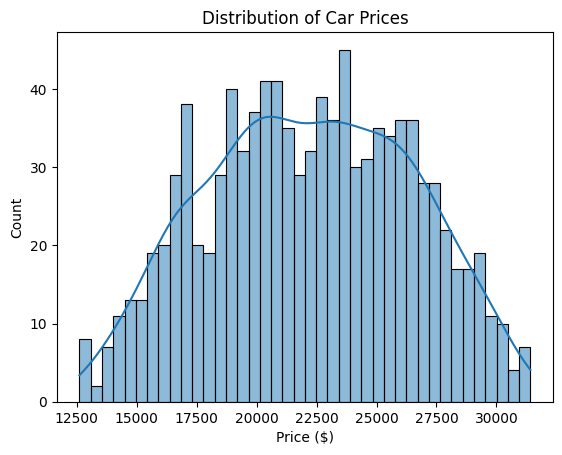

In [9]:
# histogram showing distribution of prices
sns.histplot(data=cars, x='Price', kde=True, bins=40)
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution of car prices.png")
plt.show()

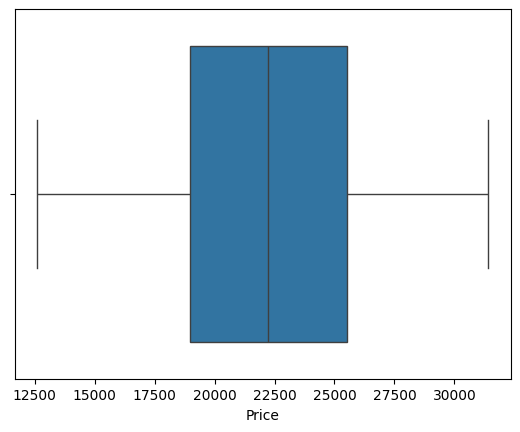

In [10]:
#boxplot showing distribution of prices
sns.boxplot(data=cars, x = 'Price')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution of car prices-boxplot.png")
plt.show()

In [11]:
print(f"Mean Price:   {cars['Price'].mean():,.2f}")
print(f"Median Price: {cars['Price'].median():,.2f}")
print(f"Skewness:     {cars['Price'].skew():.2f}")
print(f"Outliers:     {((cars['Price'] < cars['Price'].quantile(0.01)) | (cars['Price'] > cars['Price'].quantile(0.99))).sum()}")

Mean Price:   22,195.21
Median Price: 22,247.88
Skewness:     -0.03
Outliers:     20


- Year distribution - How old are most of the cars?

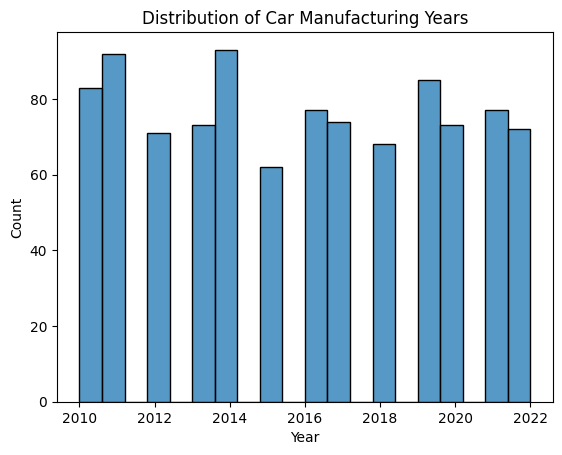

In [12]:
# histplot showing distribution of car years
sns.histplot(data=cars, x='Year', bins=20, kde=False)
plt.title('Distribution of Car Manufacturing Years')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution of car year-histplot.png")
plt.show()

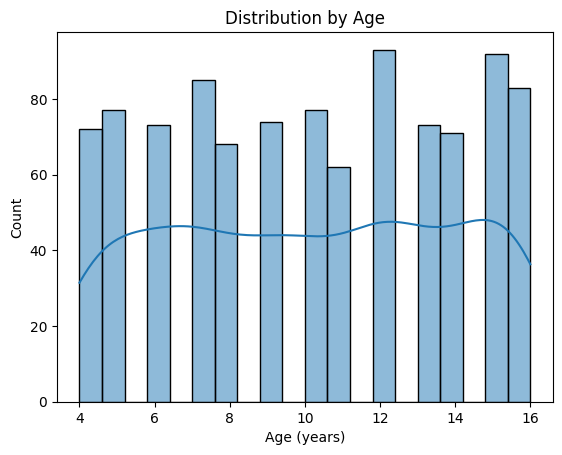

In [13]:
# Create an Age column
current_year = datetime.datetime.now().year
cars['Age'] = current_year - cars['Year']

# Age distribution
sns.histplot(data=cars, x='Age', bins=20, kde=True)
plt.title('Distribution by Age')
plt.xlabel('Age (years)')

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution by age.png")
plt.show()

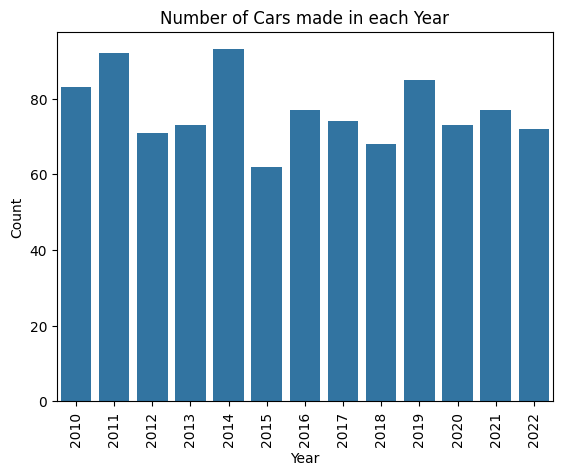

In [14]:
year_counts = cars['Year'].value_counts().sort_index()

sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Number of Cars made in each Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\number of cars in each year.png")
plt.show()

In [15]:
print(f"Oldest cars:   {cars['Year'].min()} ({current_year - cars['Year'].min()} years old)")
print(f"Newest cars:   {cars['Year'].max()}")
print(f"Average year: {cars['Year'].mean():.0f}")
print(f"Most cars were made on year {cars['Year'].mode()[0]}")

Oldest cars:   2010 (16 years old)
Newest cars:   2022
Average year: 2016
Most cars were made on year 2014


- Mileage distribution — identify high-mileage vs low-mileage segments

In [16]:
# Define mileage segments
def mileage_segment(mileage):
    if mileage < 30000:
        return 'Low (< 30k)'
    elif mileage < 70000:
        return 'Medium (30k–70k)'
    elif mileage < 120000:
        return 'High (70k–120k)'
    else:
        return 'Very High (> 120k)'

cars['Mileage_Segment'] = cars['Mileage'].apply(mileage_segment)

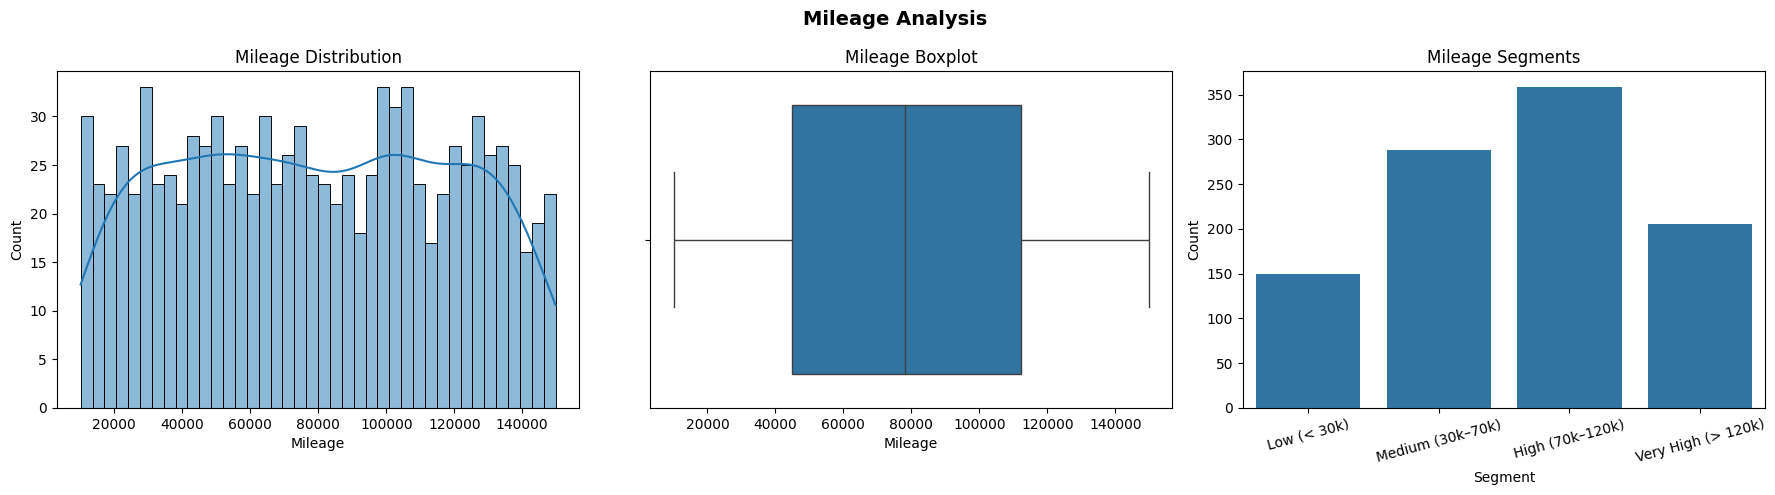

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram with KDE
sns.histplot(data=cars, x='Mileage', kde=True, bins=40, ax=axes[0])
axes[0].set_title('Mileage Distribution')
axes[0].set_xlabel('Mileage')

# 2. Boxplot — spot outliers
sns.boxplot(data=cars, x='Mileage', ax=axes[1])
axes[1].set_title('Mileage Boxplot')
axes[1].set_xlabel('Mileage')

# 3. Segment breakdown — bar chart
segment_order = ['Low (< 30k)', 'Medium (30k–70k)', 'High (70k–120k)', 'Very High (> 120k)']
segment_counts = cars['Mileage_Segment'].value_counts().reindex(segment_order)
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=axes[2])
axes[2].set_title('Mileage Segments')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Mileage Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\mileage analysis.png")
plt.show()

In [18]:
print(f"Lowest Mileage:   {cars['Mileage'].min():,}")
print(f"Highest Mileage:  {cars['Mileage'].max():,}")
print(f"Average Mileage:  {cars['Mileage'].mean():,.0f}")
print(f"Median Mileage:   {cars['Mileage'].median():,.0f}")
print(f"Skewness:         {cars['Mileage'].skew():.2f}")
print()
print("--- Segment Breakdown ---")
print(cars['Mileage_Segment'].value_counts().reindex(segment_order))

Lowest Mileage:   10,079
Highest Mileage:  149,794
Average Mileage:  78,797
Median Mileage:   78,056
Skewness:         0.01

--- Segment Breakdown ---
Mileage_Segment
Low (< 30k)           149
Medium (30k–70k)      288
High (70k–120k)       358
Very High (> 120k)    205
Name: count, dtype: int64


### Price analysis and visualization

- Price vs Mileage

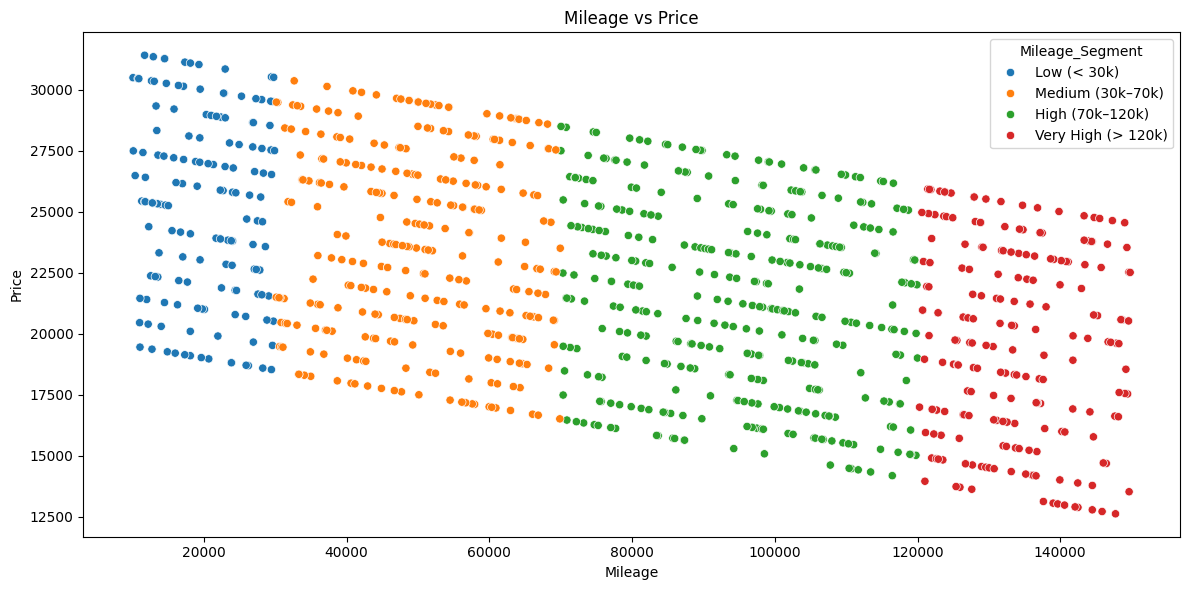

In [21]:
#check whether mileage correlates with price
plt.figure(figsize=(12,6))
sns.scatterplot(data=cars, x='Mileage', y='Price', hue='Mileage_Segment')
plt.title('Mileage vs Price')
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Mileage vs price.png")
plt.show()

there is negative correlation between price and mileage

- Price vs Year — do newer cars command higher prices? (scatter/line)

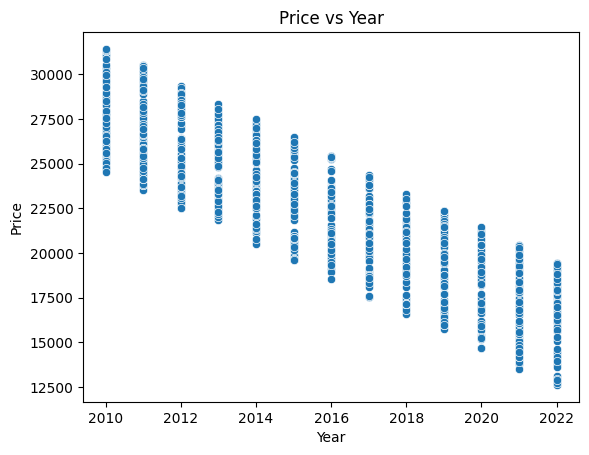

In [26]:
# scatterplot price vs year
sns.scatterplot(data=cars, x='Year', y='Price')
plt.title("Price vs Year")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\scatterplot price vs year.png")
plt.show()

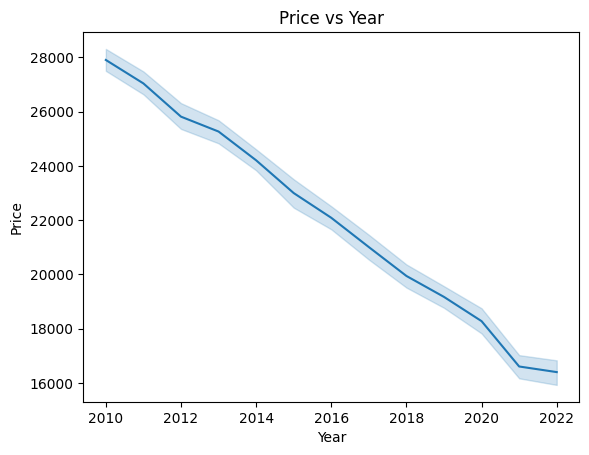

In [27]:
#line trend with years
sns.lineplot(data=cars, x='Year', y='Price')
plt.title("Price vs Year")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\line trend with years.png")
plt.show()

there is a high negative correlation between price and year

- Price vs Condition — boxplot per condition category

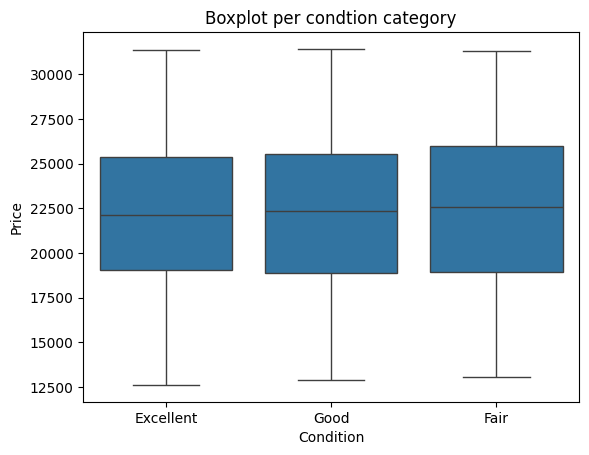

In [30]:
#boxplot per condition category
sns.boxplot(data=cars, x='Condition', y='Price')
plt.title("Boxplot per condtion category")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Boxplot per condition category.png")
plt.show()

- Price by Make — which brands hold value best? (grouped bar or boxplot)

In [38]:
price_by_make = cars.groupby("Make")["Price"].mean().reset_index()
print("\n Brands and their values: ")
price_by_make


 Brands and their values: 


,Make,Price
0,Chevrolet,21957.203589
1,Ford,22354.415578
2,Honda,22238.084171
3,Nissan,22587.502128
4,Toyota,21881.913415


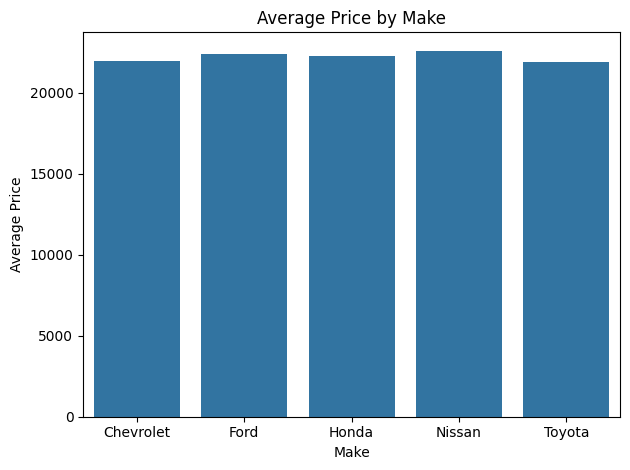

In [42]:
#price per make
sns.barplot(data=price_by_make, x='Make', y='Price')
plt.title('Average Price by Make')
plt.xlabel('Make')
plt.ylabel('Average Price')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Average price by make.png")
plt.tight_layout()
plt.show()

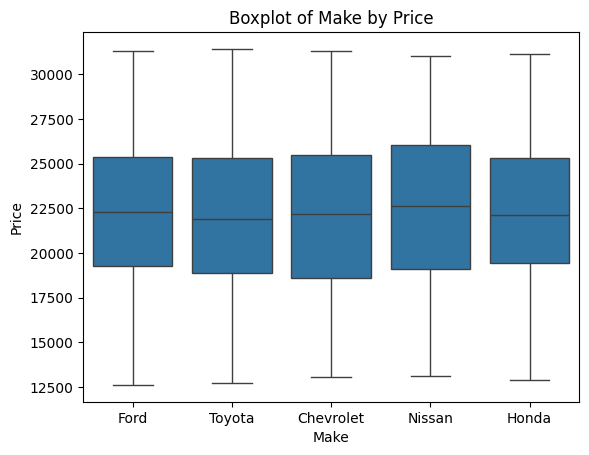

In [45]:
sns.boxplot(data=cars, x="Make", y="Price")
plt.title("Boxplot of Make by Price")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\make by price.png")
plt.show()

- Price by Make + Condition — heatmap of average prices

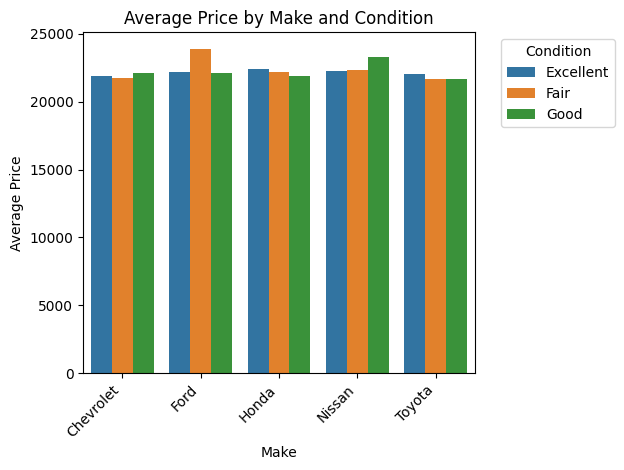

In [47]:
avg_price = cars.groupby(['Make', 'Condition'])['Price'].mean().reset_index()

sns.barplot(data=avg_price, x='Make', y='Price', hue='Condition')
plt.title('Average Price by Make and Condition')
plt.xlabel('Make')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\price by make + condition.png")
plt.show()

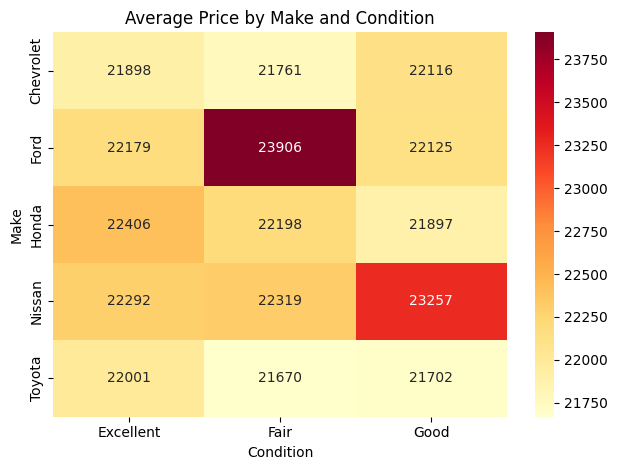

In [50]:
# Create a pivot table
pivot = cars.pivot_table(values='Price', index='Make', columns='Condition', aggfunc='mean')

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Average Price by Make and Condition')
plt.xlabel('Condition')
plt.ylabel('Make')
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\heatmap-average price by make and condition.png")
plt.show()

### Depriciation and Value retention

- Price vs Age (current year − Year) — depreciation curve